In [1]:
import yfinance as yf
import ta
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:
snp500=yf.download("%5EGSPC", period="40y")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
print(snp500["Close"]["%5EGSPC"])
snp500_price_data=snp500["Close"]["%5EGSPC"]
print(type(snp500_price_data))
print(type(snp500_price_data.squeeze()))

Date
1985-04-12     180.539993
1985-04-15     180.919998
1985-04-16     181.199997
1985-04-17     181.679993
1985-04-18     180.839996
                 ...     
2025-04-07    5062.250000
2025-04-08    4982.770020
2025-04-09    5456.899902
2025-04-10    5268.049805
2025-04-11    5363.359863
Name: %5EGSPC, Length: 10079, dtype: float64
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [4]:
ma_200=ta.trend.sma_indicator(snp500_price_data, window=200)
print(ma_200)
ma_200=ma_200[200:]
snp500_price_data=snp500_price_data[200:]

Date
1985-04-12            NaN
1985-04-15            NaN
1985-04-16            NaN
1985-04-17            NaN
1985-04-18            NaN
                 ...     
2025-04-07    5758.174749
2025-04-08    5755.722749
2025-04-09    5755.684148
2025-04-10    5754.785046
2025-04-11    5754.255347
Name: sma_200, Length: 10079, dtype: float64


In [5]:
ma_toprice_ratio=snp500_price_data/ma_200

In [6]:
ma_to_price_perc=(ma_toprice_ratio-1) *100
print(ma_to_price_perc)

Date
1986-01-28     9.181843
1986-01-29     9.348063
1986-01-30     8.769330
1986-01-31     9.956379
1986-02-03    10.992810
                ...    
2025-04-07   -12.085857
2025-04-08   -13.429291
2025-04-09    -5.191116
2025-04-10    -8.457922
2025-04-11    -6.793155
Length: 9879, dtype: float64


In [7]:
years=ma_to_price_perc.index.year

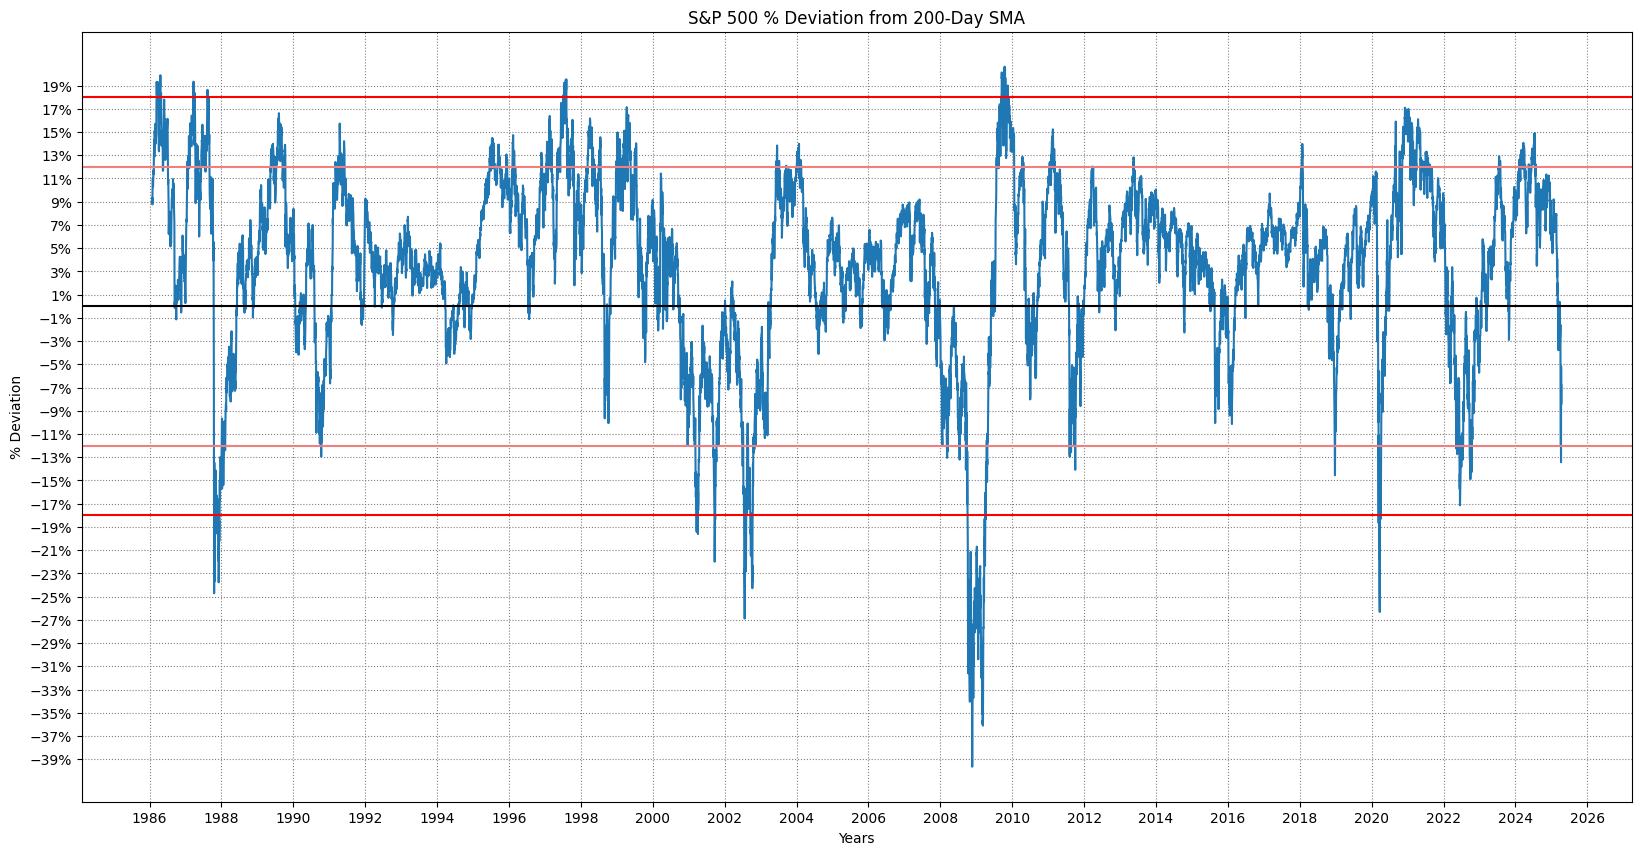

In [8]:
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
fig, ax= plt.subplots(figsize=(20,10))
ax.grid(True, color="grey", linestyle=":") 
ax.plot(ma_to_price_perc)
ax.axhline(y=0, color="black")
ax.axhline(y=12, color="lightcoral")
ax.axhline(y=-12, color="lightcoral")
ax.axhline(y=18, color="red")
ax.axhline(y=-18, color="red")
ax.set_yticks(np.arange(int(ma_to_price_perc.min()), int(ma_to_price_perc.max()), 2))
ax.yaxis.set_major_formatter(PercentFormatter(100))
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.set_xlabel("Years")
ax.set_ylabel("% Deviation")
plt.title("S&P 500 % Deviation from 200-Day SMA")
plt.show()


In [9]:
sorted_ma_perc_values=ma_to_price_perc.sort_values()[:400]
print(sorted_ma_perc_values.min())
print(sorted_ma_perc_values.max())

-39.6456696155066
-11.935891379467167


In [10]:
pd.to_datetime(3)


Timestamp('1970-01-01 00:00:00.000000003')

400
398
398
[np.float64(144.04545230738182), np.float64(167.57344120513866), np.float64(165.83026467466084), np.float64(135.4173799628493), np.float64(165.6276366056601), np.float64(134.7459893891846), np.float64(159.6695118125503), np.float64(158.57165133791463), np.float64(124.26622715774043), np.float64(134.85473781265458), np.float64(156.52801750598604), np.float64(126.56541192142727), np.float64(129.51071951678665), np.float64(122.13376957883746), np.float64(146.2562590531894), np.float64(149.25234323462487), np.float64(158.20094833504467), np.float64(118.15771725983213), np.float64(158.454365863362), np.float64(128.8000760243493), np.float64(128.17870089576294), np.float64(129.85114157308692), np.float64(129.6817772440061), np.float64(116.75650720489472), np.float64(128.53614876634796), np.float64(120.87046973342942), np.float64(119.78780689941159), np.float64(145.71173640284906), np.float64(124.21384740253045), np.float64(140.3328134508082), np.float64(143.03870677594475), np.fl

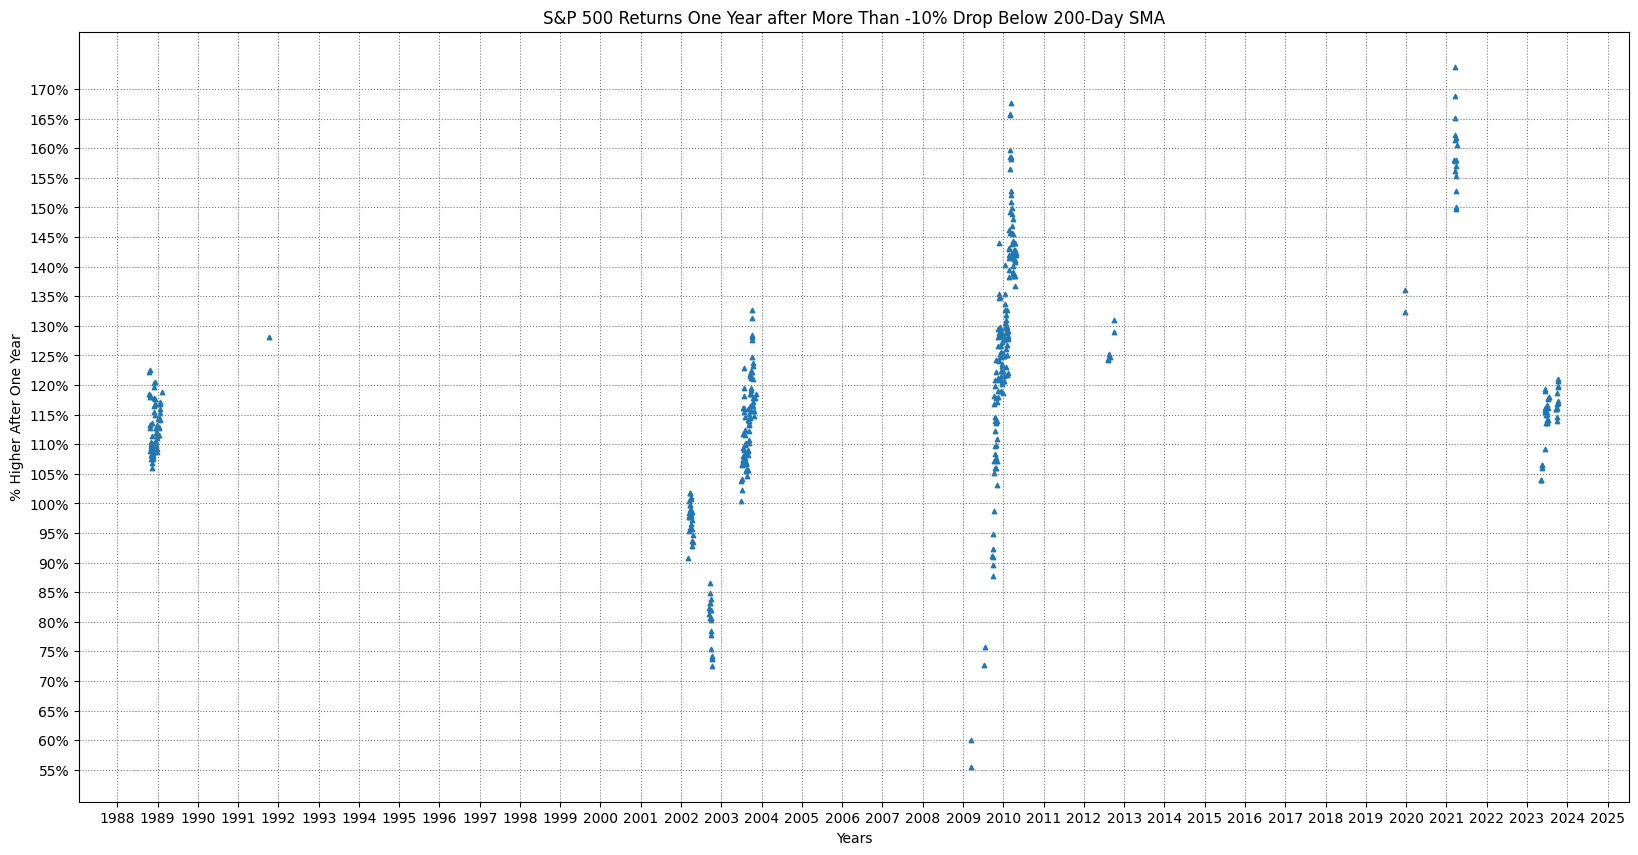

In [11]:

drawdown_dates=sorted_ma_perc_values.index
one_year_later=sorted_ma_perc_values.index +pd.DateOffset(years=1)
data_not_found_list=[]
price_data_one_year_later=[]
price_increase_perc_one_year_later=[]

for i,j in zip(one_year_later,drawdown_dates):
    found=False
    day_offset=0
    while found==False and day_offset<11:
        date=i - pd.Timedelta(days=day_offset)
        try:
            price_data_one_year_later.append(snp500_price_data.loc[date])
            price_increase_perc_one_year_later.append(snp500_price_data.loc[date]/snp500_price_data.loc[j] *100   -1 )
            found=True
        except:
            day_offset+=1
            # print(f"data not found for {i} setting dayoffset {day_offset}")
            if day_offset==10:
                data_not_found_list.append(i)
                break
            # try:
            #     # data_not_found_list.append(i)
            #     print("data not found")
            #     shifted_date=i - pd.Timedelta(day_offset)
            #     price_data_one_year_later.append(snp500_price_data.loc[shifted_date])
            #     price_increase_perc_one_year_later.append(snp500_price_data.loc[shifted_date]/snp500_price_data.loc[j] *100   -1 )
            # except:

print(len(one_year_later))
one_year_later = one_year_later[~one_year_later.isin(data_not_found_list)]
print(len(one_year_later))
print(len(price_increase_perc_one_year_later))
print(price_increase_perc_one_year_later)
fig, returns= plt.subplots(figsize=(20,10))
returns.xaxis.set_major_locator(mdates.YearLocator(1))
returns.yaxis.set_major_formatter(PercentFormatter(100))
returns.grid(True, color="grey", linestyle=":") 
returns.set_yticks(np.arange(int(min(price_increase_perc_one_year_later)), int(max(price_increase_perc_one_year_later)), 5))
returns.set_xlabel("Years")
returns.set_ylabel("% Higher After One Year")
plt.title("S&P 500 Returns One Year after More Than -10% Drop Below 200-Day SMA")
returns.scatter(one_year_later,price_increase_perc_one_year_later,marker='^', s=10)


In [12]:
median = np.median(price_increase_perc_one_year_later)
mean= np.mean(price_increase_perc_one_year_later)
print(f"Median returns {median}")
print(f"Mean returns {mean}")

Median returns 116.73387904280885
Mean returns 118.36616511403254
